<a href="https://colab.research.google.com/github/grubbylu/AI-bad-corn-seed-detector/blob/main/AI_corn_seed_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import os
import re
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
import glob
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
#from keras.utils.vis_utils import plot_model
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score
import itertools
from pathlib import Path
import keras
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import applications
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dense, Dropout
from keras.preprocessing import image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/Dataset/train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/Dataset/test.csv')
main_path = "/content/drive/MyDrive/Dataset/"
df_train.head()

,seed_id,view,image,label
0,0,top,train/00000.png,broken
1,1,bottom,train/00001.png,pure
2,3,top,train/00003.png,broken
3,4,top,train/00004.png,pure
4,5,top,train/00005.png,discolored


In [ ]:
df_test.head()

,seed_id,view,image
0,2,top,test/00002.png
1,11,bottom,test/00011.png
2,13,top,test/00013.png
3,19,bottom,test/00019.png
4,27,bottom,test/00027.png


In [ ]:
for index in df_train['label'].index:
  if df_train['label'].values[index] == "pure":
    df_train['label'].values[index] = "good"
  else:
    df_train['label'].values[index] = "bad"




In [ ]:
freq = df_train['label'].value_counts()
print(freq)

bad     8485
good    5837
Name: label, dtype: int64


In [ ]:
from sklearn.utils import resample

def create_balanced_df(in_df):
    # sort the frequencies for each label
    freq = in_df['label'].value_counts()
    # create initial dataframe with the majority class.
    balanced_df = in_df[in_df.label == freq.index[0]]
    #upsample minority classes to the majority class instances
    for lbl in freq.index[1:]:
        df = in_df[in_df.label == lbl]
        df_upsampled = resample(df, replace = True, n_samples = freq[0])
        balanced_df = pd.concat([balanced_df, df_upsampled])
    # shuffle the DataFrame rows
    balanced_df = balanced_df.sample(frac = 1)
    return balanced_df

In [ ]:
df_train.head()

,seed_id,view,image,label
0,0,top,train/00000.png,bad
1,1,bottom,train/00001.png,good
2,3,top,train/00003.png,bad
3,4,top,train/00004.png,good
4,5,top,train/00005.png,bad


In [ ]:
df_train = create_balanced_df(df_train)
freq = df_train['label'].value_counts()
print(freq)

bad     8485
good    8485
Name: label, dtype: int64


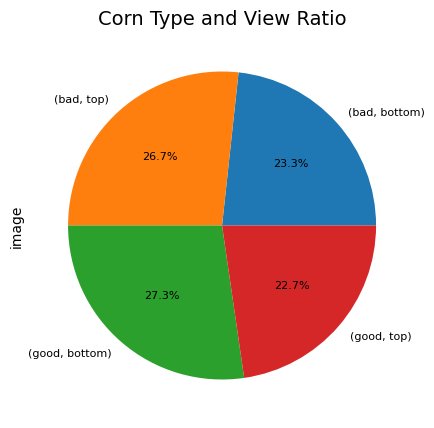

In [ ]:
ax = df_train.groupby(['label','view'])['image'].count().plot(kind='pie',figsize=(5,5),title='Corn Type and View Ratio',autopct='%1.1f%%',shadow=False,fontsize=8);
ax.title.set_size(14)

In [ ]:
# Detect hardware
try:
  tpu_resolver = tf.distribute.cluster_resolver.TPUClusterResolver() # TPU detection
except ValueError:
  tpu_resolver = None
  gpus = tf.config.experimental.list_logical_devices("GPU")

# Select appropriate distribution strategy
if tpu_resolver:
  tf.config.experimental_connect_to_cluster(tpu_resolver)
  tf.tpu.experimental.initialize_tpu_system(tpu_resolver)
  strategy = tf.distribute.TPUStrategy(tpu_resolver)
  print('Running on TPU ', tpu_resolver.cluster_spec().as_dict()['worker'])
elif len(gpus) > 1:
  strategy = tf.distribute.MirroredStrategy([gpu.name for gpu in gpus])
  print('Running on multiple GPUs ', [gpu.name for gpu in gpus])
elif len(gpus) == 1:
  strategy = tf.distribute.get_strategy() # default strategy that works on CPU and single GPU
  print('Running on single GPU ', gpus[0].name)
else:
  strategy = tf.distribute.get_strategy() # default strategy that works on CPU and single GPU
  print('Running on CPU')

print("Number of accelerators: ", strategy.num_replicas_in_sync)

Running on single GPU  /device:GPU:0
Number of accelerators:  1


In [ ]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

# Import series of helper functions for our notebook
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, compare_historys, walk_through_dir, pred_and_plot

--2023-11-30 16:51:10--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2023-11-30 16:51:10 (125 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [ ]:
FINE_TUNING_EPOCHS = 10
TRAINING_EPOCHS = 10
BATCH_SIZE = 32 * strategy.num_replicas_in_sync

image_height = 224
image_width = 224

In [ ]:
gen = ImageDataGenerator(
                          rescale = 1./255.,
                          horizontal_flip = True,
                          vertical_flip = True,
                          zoom_range = 0.05,
                          rotation_range = 90,
                          validation_split = 0.2 # training: 80% data, validation: 20% data
                         )

train_generator = gen.flow_from_dataframe(
    df_train, # dataframe
    directory = main_path, # images data path / folder in which images are there
    x_col = 'image',
    y_col = 'label',
    subset = "training",
    color_mode = "rgb",
    target_size = (image_height, image_width), # image height , image width
    class_mode = "categorical",
    batch_size = BATCH_SIZE,
    shuffle = True,
    seed = 42,
)

validation_generator = gen.flow_from_dataframe(
    df_train, # dataframe
    directory = main_path, # images data path / folder in which images are there
    x_col = 'image',
    y_col = 'label',
    subset="validation",
    color_mode="rgb",
    target_size = (image_height, image_width), # image height , image width
    class_mode = "categorical",
    batch_size = BATCH_SIZE,
    shuffle= False,
    seed = 42,
)

Found 13576 validated image filenames belonging to 2 classes.
Found 3394 validated image filenames belonging to 2 classes.


In [ ]:
# Data agumentation and pre-processing using tensorflow
test_gen = ImageDataGenerator(rescale = 1./255.)

test_generator = test_gen.flow_from_dataframe(
    df_test, # dataframe
    directory = main_path, # images data path / folder in which images are there
    x_col = 'image',
    color_mode ="rgb",
    target_size = (image_height, image_width), # image height , image width
    batch_size = BATCH_SIZE,
    class_mode = None,
    shuffle = False,
)

Found 3479 validated image filenames.


In [ ]:
from sklearn.utils import class_weight

class_weight = class_weight.compute_class_weight(class_weight = "balanced", classes = np.unique(train_generator.classes), y = train_generator.classes)
class_weight = dict(enumerate(class_weight))

# if the data has been balanced it should all be 1s
print(class_weight)

{0: 0.9989698307579102, 1: 1.001032296121516}


In [ ]:
# Define function to plot some images

def plot_images(img, true_labels, predictions = None):
    plt.figure(figsize=[12, 18])
    for i in range(24):
        plt.subplot(6, 4, i+1)
        plt.imshow(img[i])
        plt.axis('off')
        if (predictions is not None):
            plt.title("{}\n {} {:.1f}%".format(class_names[np.argmax(true_labels[i])], class_names[np.argmax(predictions[i])], 100 * np.max(predictions[i])))
        else:
            plt.title(class_names[np.argmax(true_labels[i])])

In [ ]:
a = train_generator.class_indices
class_names = list(a.keys())  # storing class/breed names in a list

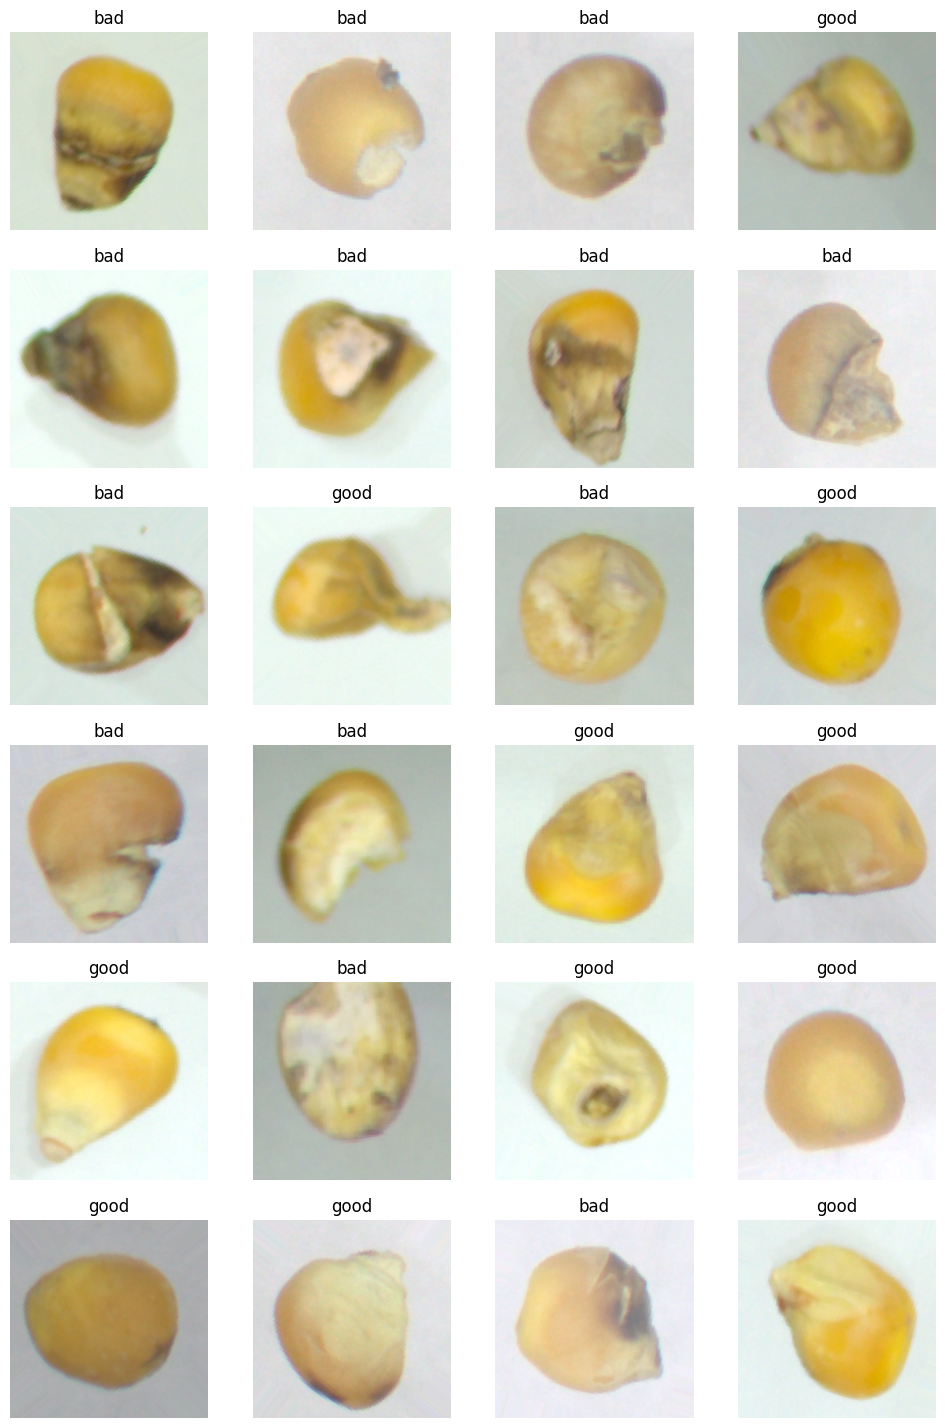

In [ ]:
x,y = next(train_generator)
plot_images(x,y)

In [ ]:
# function to plote training history
def plot_history(history):
    # store results
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    # plot results
    # accuracy
    plt.figure(figsize=(5, 8))
    plt.rcParams['figure.figsize'] = [8, 4]
    plt.rcParams['font.size'] = 10
    plt.rcParams['axes.grid'] = True
    plt.rcParams['figure.facecolor'] = 'white'
    plt.subplot(2, 1, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.ylabel('Accuracy')
    plt.title(f'\nTraining and Validation Accuracy. \nTrain Accuracy: {str(round(acc[-1],3))}\nValidation Accuracy: {str(round(val_acc[-1],3))}')

    # loss
    plt.subplot(2, 1, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.ylabel('Cross Entropy')
    plt.title(f'Training and Validation Loss. \nTrain Loss: {str(round(loss[-1],3))}\nValidation Loss: {str(round(val_loss[-1],3))}')
    plt.xlabel('epoch')
    plt.tight_layout(pad=3.0)
    plt.show()

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_heatmap(y_true, y_pred, class_names, ax, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        square=True,
        xticklabels=class_names,
        yticklabels=class_names,
        fmt='d',
        cmap=plt.cm.Blues,
        cbar=False,
        ax=ax
    )
    ax.set_title(title, fontsize = 12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha = "right")
    ax.set_ylabel('True Label', fontsize= 10)
    ax.set_xlabel('Predicted Label', fontsize = 10)

In [ ]:
from tensorflow.keras.models import Model

def create_model(base_model):

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation = 'relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation = 'relu')(x)
    x = Dropout(0.2)(x)

    outputs = Dense(len(class_names), activation='softmax')(x)

    model = Model(base_model.inputs, outputs)

    return model

In [ ]:
def fit_model(model, base_model, epochs, fine_tune = 0):

    early = tf.keras.callbacks.EarlyStopping( patience = 10,
                                              min_delta = 0.001,
                                              restore_best_weights = True)
    # early stopping call back

    # Defines how many layers to freeze during training.
    # Layers in the convolutional base are switched from trainable to non-trainable
    # depending on the size of the fine-tuning parameter.
    conv_base = base_model

    print("Unfreezing number of layers in base model = ", fine_tune)
    if fine_tune > 0:
        conv_base.trainable = True
        for layer in conv_base.layers[:-fine_tune]:
            layer.trainable = False
        # small learning rate for finte tuning
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                      loss=tf.keras.losses.BinaryCrossentropy(),
                      metrics=['accuracy'])
    else:
        conv_base.trainable = False
        model.compile(optimizer=tf.keras.optimizers.Adam(),
                      loss=tf.keras.losses.BinaryCrossentropy(),
                      metrics=['accuracy'])

    # categorical cross entropy is taken since its used as a loss function for
    # multi-class classification problems where there are two or more output labels.
    # using Adam optimizer for better performance
    # other optimizers such as sgd can also be used depending upon the model

    # fit model
    history = model.fit(train_generator,
                        validation_data = validation_generator,
                        epochs = epochs,
                        callbacks = [early],
                        class_weight = class_weight
                       )

    return history

In [ ]:
with strategy.scope():
    # load the VGG16 architecture with imagenet weights as base
    vgg19_base_model = tf.keras.applications.vgg19.VGG19(
                             include_top = False,
                             weights = 'imagenet',
                             input_shape = (image_height, image_width, 3)
                             )

    # For freezing the layer we make use of layer.trainable = False
    # means that its internal state will not change during training.
    # model's trainable weights will not be updated during fit(),
    # and also its state updates will not run.
    vgg19_model = create_model(vgg19_base_model)

In [ ]:
history = fit_model(vgg19_model, vgg19_base_model, epochs = TRAINING_EPOCHS)

In [ ]:
vgg19_model.save("Vgg19Model.h5")

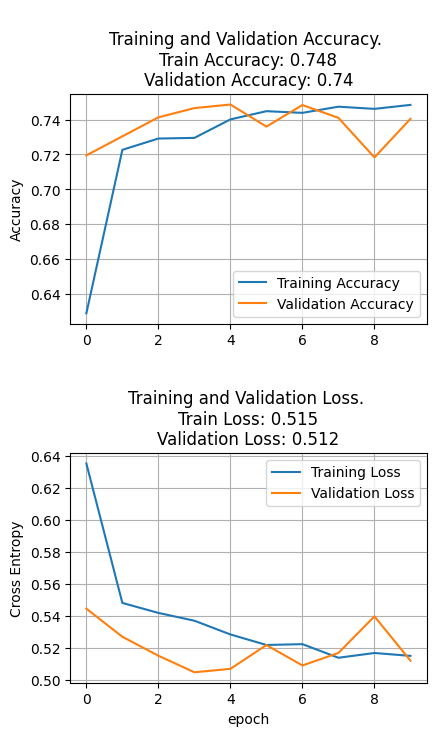

In [ ]:
plot_history(history)

In [ ]:
vgg19_model = tf.keras.models.load_model("Vgg19Model.h5")

In [ ]:
with strategy.scope():
    # Unfreeze the base_model. Note that it keeps running in inference mode
    # since we passed `training=False` when calling it. This means that
    # the batchnorm layers will not update their batch statistics.
    # This prevents the batchnorm layers from undoing all the training
    # we've done so far.
    nr_base_layers = len(vgg19_base_model.layers)
    print("VGG19 base layers = ", nr_base_layers)

    history = fit_model(vgg19_model, vgg19_base_model, epochs = FINE_TUNING_EPOCHS, fine_tune = int(nr_base_layers))

NameError: ignored

In [ ]:
vgg19_model.save("Vgg19Model.h5")

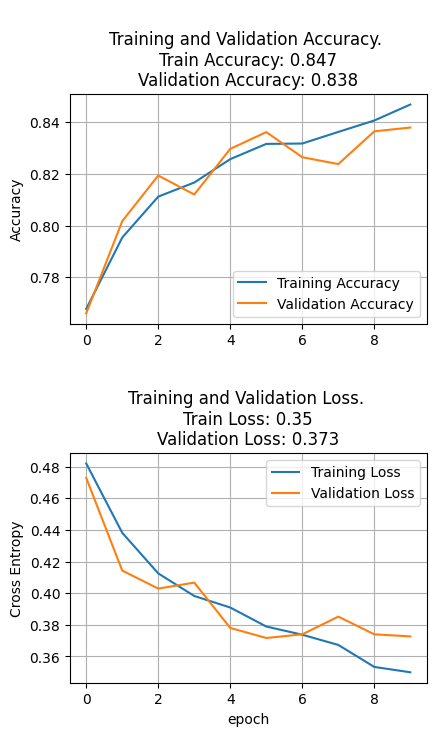

In [ ]:
plot_history(history)

In [ ]:
# Perform predictions to allow computation of the confusion matrix later on
# Do not shuffle predictions otherwise we have no way of finding out the true labels
validation_generator.reset()

vgg19_val_preds = vgg19_model.predict(validation_generator)
vgg19_val_pred_classes = np.argmax(vgg19_val_preds, axis=1)

107/107 [==============================] - 2493s 23s/step


In [ ]:
accuracy_score = vgg19_model.evaluate(validation_generator)

print("Accuracy: {:.2f}%".format(accuracy_score[1] * 100))
print("Loss: {:.3f}".format(accuracy_score[0]))

107/107 [==============================] - 41s 380ms/step - loss: 0.3688 - accuracy: 0.8379
Accuracy: 83.79%
Loss: 0.369


In [ ]:
vgg19_model.metrics

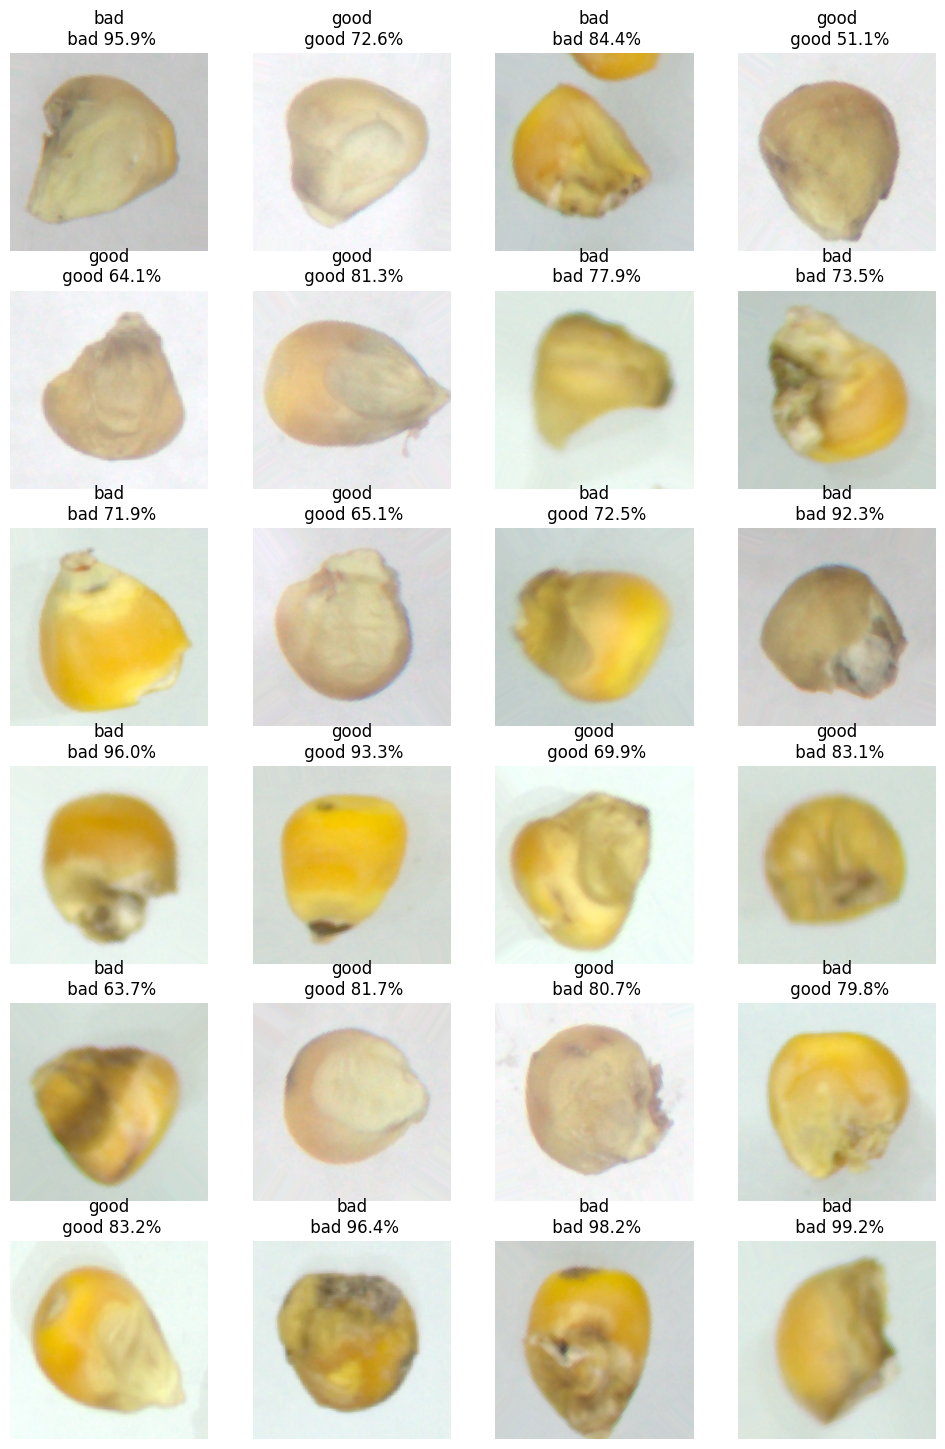

In [ ]:
validation_generator.reset()
x, y = next(validation_generator)
plot_images(x, y, vgg19_val_preds)

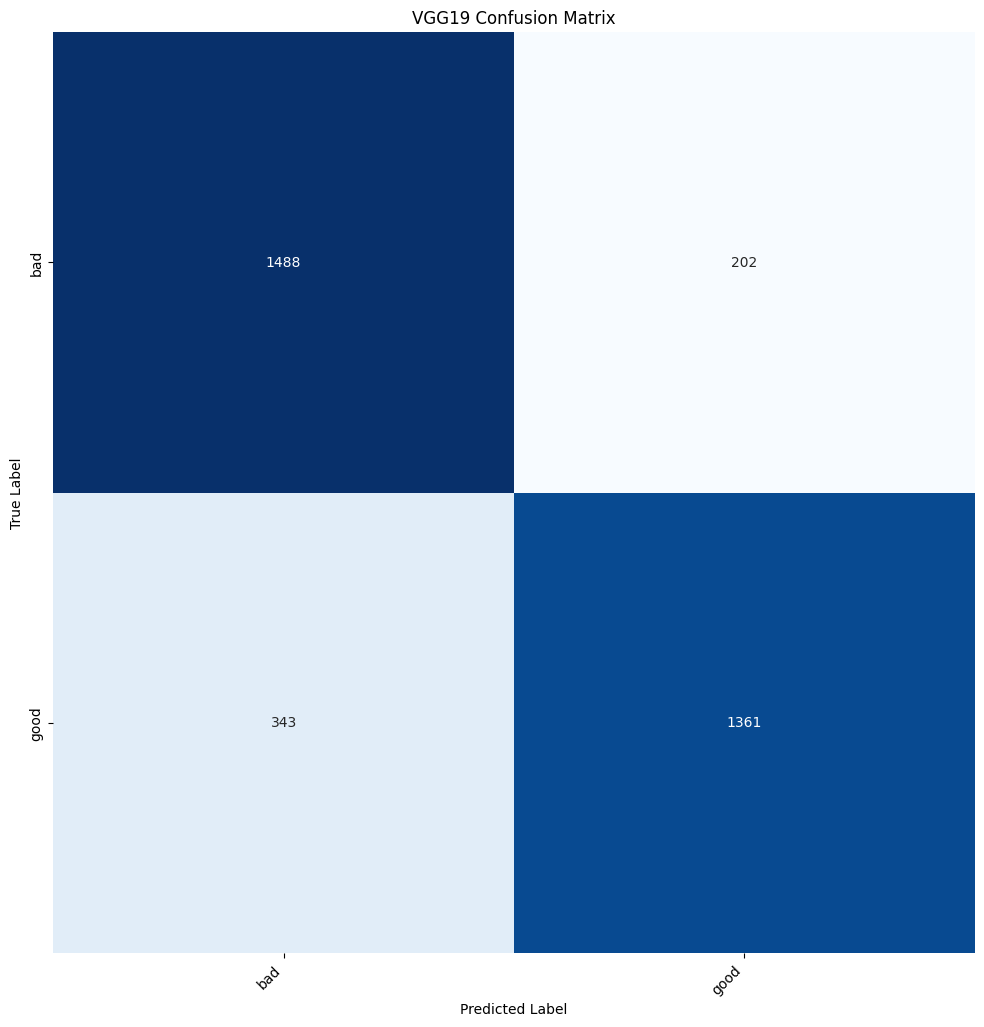

In [ ]:
fig, (ax2) = plt.subplots(figsize=(15, 8))

true_classes = validation_generator.classes

plot_heatmap(true_classes, vgg19_val_pred_classes, class_names, ax2, title = "VGG19 Confusion Matrix")

fig.tight_layout()
fig.subplots_adjust(top=1.25)
plt.show()

In [ ]:
precision_score(true_classes, vgg19_val_pred_classes, average = 'weighted')

0.8418358239625421

In [ ]:
recall_score(true_classes, vgg19_val_pred_classes, average = 'weighted')

0.8394225103123159